In [1]:
from Aplha_n_methods import Alpha_N_calc as an
from Geometry_methods import Geometry_helper as gh

from scipy.optimize import curve_fit
import numpy as np
import openmc
import matplotlib.pyplot as plt


In [2]:
#Getting material 
mats = openmc.Materials.from_xml('materials.xml')

energy span 2000 8000
Waiting for SRModule to produce output...
end of file
parameters and there error
3.07e+07 ± 4e+05
3.01e-06 ± 6e-08
-1.08 ± 0.1


/tmp/ipykernel_583/3353857956.py:13: RuntimeWarning: invalid value encountered in log
  return A*np.log(B*E)/E + C


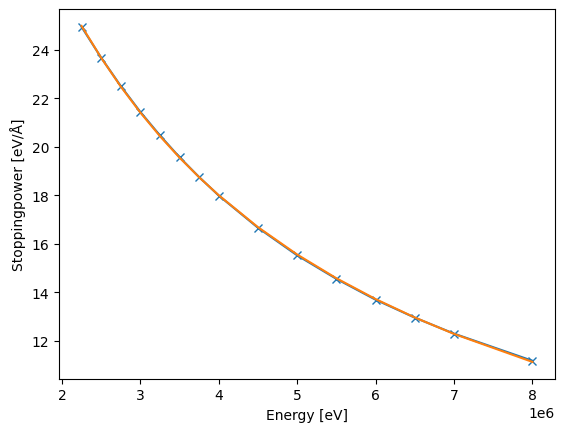

In [25]:
fuel_name= 'Fuel_A'
mat = gh.get_material_by_name(fuel_name,mats)
energies,stopping_powers = an.SR_file_write_and_read(mat,E_min=2000,E_max=8000,new_file=False)

fig,ax = plt.subplots()
ax.plot(energies,stopping_powers,'x-',label=fuel_name)
ax.set_xlabel('Energy [eV]')
ax.set_ylabel('Stoppingpower [eV/Å]')


def bethe_tail(E, A, B, C):
    E=np.array(E)
    return A*np.log(B*E)/E + C
def uncertainties_from_cov(popt,cov):
    err=[]
    print('parameters and there error')
    for n in range(len(cov)):
        err.append(np.sqrt(cov[n,n]))
        print(f'{popt[n]:.3g} ± {np.sqrt(cov[n,n]):.1g}')
    return err
    

popt, cov = curve_fit(
    bethe_tail,
    energies, stopping_powers,
    p0=[50, 1, 0]
)

stopping_powers_fit = bethe_tail(energies, *popt)
ax.plot(energies,stopping_powers_fit,label='fit')


err = uncertainties_from_cov(popt,cov)

/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)


Text(0, 0.5, 'Alpha signal [$\\alpha$/s]')

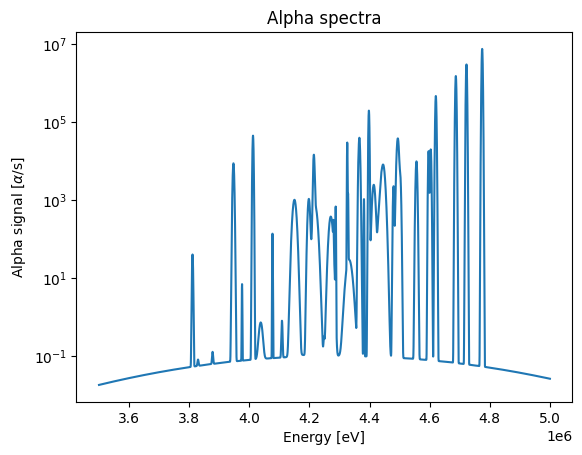

In [45]:
#Introducing alpha spectra and make sure to it is possible to calculate with the to data sets
alpha_decays, mass = an.alpha_decay_values_from_material(mat)
alpha_spectra,energies = an.energy_spectra_gaussian(alpha_decays,x=None)
stopping_powers_fit = bethe_tail(energies, *popt)

fig, ax = plt.subplots()
#ax.plot(energies,alpha_spectra/stopping_powers_fit)
ax.plot(energies,alpha_spectra)
ax.semilogy()
ax.set_title('Alpha spectra')
ax.set_xlabel('Energy [eV]')
ax.set_ylabel(r'Alpha signal [$\alpha$/s]')




[2.5e+05 5.0e+05 1.0e+06 2.0e+06 3.0e+06 4.0e+06 5.0e+06 6.0e+06 7.0e+06
 8.0e+06 9.0e+06 1.0e+07 1.1e+07 1.2e+07 1.3e+07 1.4e+07 1.5e+07 1.6e+07
 1.7e+07 1.8e+07 1.9e+07 2.0e+07 2.2e+07 2.4e+07 2.6e+07 2.8e+07 3.0e+07
 3.5e+07 4.0e+07 4.5e+07 5.0e+07 5.5e+07 6.0e+07 6.5e+07 7.0e+07 7.5e+07
 8.0e+07 9.0e+07 1.0e+08 1.1e+08 1.2e+08 1.3e+08 1.4e+08 1.5e+08 1.6e+08
 1.8e+08 2.0e+08]
[4.594420e-09 2.224867e-05 6.208476e-03 1.367750e-01 3.509141e-01
 4.523950e-01 5.059813e-01 5.672582e-01 6.335012e-01 6.865144e-01
 7.253409e-01 7.564127e-01 7.805371e-01 8.046841e-01 8.266785e-01
 8.426465e-01 8.527411e-01 8.584822e-01 8.604258e-01 8.590306e-01
 8.544781e-01 8.471643e-01 8.248789e-01 8.345978e-01 8.414797e-01
 8.360812e-01 8.158315e-01 7.897570e-01 7.696974e-01 7.590082e-01
 7.421006e-01 7.276509e-01 7.162009e-01 7.072527e-01 6.997840e-01
 6.937521e-01 6.890090e-01 6.825060e-01 6.789493e-01 6.775126e-01
 6.776421e-01 6.788853e-01 6.809756e-01 6.837018e-01 6.869015e-01
 6.942496e-01 7.022792e

Text(0, 0.5, 'cross section [b]')

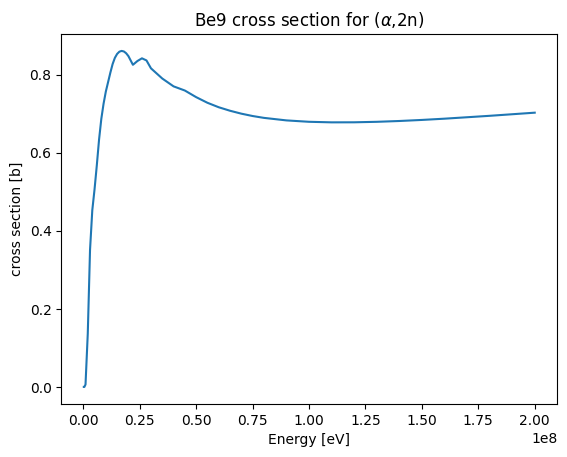

In [48]:
#Loading cross sections
from openmc.data.endf import Evaluation, get_head_record, get_tab1_record
from io import StringIO

#Also possible with .tendl files seems jendl is better but tendl is more exstensive

ev = Evaluation("/root/TENDL-a/a-Be009.tendl")

#print(ev.reaction_list)

mf3_mt107 = StringIO(ev.section[3, 3])

head = get_head_record(mf3_mt107)
params, tab = get_tab1_record(mf3_mt107)

print(tab.x)   # energies in eV
print(tab.y)   # cross sections in barns

fig, ax = plt.subplots()
ax.plot(tab.x,tab.y)
ax.set_title(r'Be9 cross section for ($\alpha$,2n)')
ax.set_xlabel('Energy [eV]')
ax.set_ylabel(r'cross section [b]')